## **Dataset Description**

The dataset provides measurements of electric power consumption in a single household located in Sceaux, France, between December 2006 and November 2010. The original data has a **one-minute** sampling rate, recording various power, voltage, and intensity metrics, along with sub-metered energy for specific appliance groups.

### **1. Attribute Information**

| Attribute | Description | Unit | Data Type |
| :--- | :--- | :--- | :--- |
| **Date** | Date in format dd/mm/yyyy | - | Categorical/Object |
| **Time** | Time in format hh:mm:ss | - | Categorical/Object |
| **Global_active_power** | Household global minute-averaged active power | kilowatt (kW) | Numerical (Continuous) |
| **Global_reactive_power**| Household global minute-averaged reactive power | kilowatt (kW) | Numerical (Continuous) |
| **Voltage** | Minute-averaged voltage | Volt (V) | Numerical (Continuous) |
| **Global_intensity** | Household global minute-averaged current intensity | Ampere (A) | Numerical (Continuous) |
| **Sub_metering_1** | Energy sub-metering No. 1 (Kitchen: dishwasher, oven, microwave) | watt-hour | Numerical (Discrete) |
| **Sub_metering_2** | Energy sub-metering No. 2 (Laundry room: washing machine, fridge, light) | watt-hour | Numerical (Discrete) |
| **Sub_metering_3** | Energy sub-metering No. 3 (Electric water-heater and air-conditioner) | watt-hour | Numerical (Discrete) |

### **2. Structure and Data Characteristics**

*   **Observations**: The `household_power_consumption.csv` file contains **1,048,575** records, representing approximately two years of minute-by-minute data.
*   **Target Variable**: `Global_active_power` is the primary variable used for forecasting in the **Seasonal ARIMA (SARIMA)** model.
*   **Missing Values**: In the original dataset, missing values are typically represented by a `?` character or left blank (NaN). These require interpolation or smoothing before model training.

### **3. Technical Notes**

*   **Residual Energy Calculation**: The active energy consumed every minute (in watt-hour) by electrical equipment not monitored through sub-meterings 1, 2, and 3 can be calculated using the following formula:
    $$\text{Residual Energy} = \left( \frac{Global\_active\_power \times 1000}{60} \right) - Sub\_metering\_1 - Sub\_metering\_2 - Sub\_metering\_3$$
*   **Missing Values Handling**: 
    *   The dataset contains missing values in the measurements, accounting for approximately **1.25%** of the total rows.
    *   While all calendar timestamps are present, specific measurement values may be absent (e.g., recorded as an empty string between separators or a `?` symbol). 
    *   Significant periods of missing data are known to occur (for instance, on **April 28, 2007**). 
    *   For the **SARIMA** model, these gaps must be addressed using techniques such as linear interpolation or forward-filling to maintain the continuity of the time series.

## **Understanding Data**

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
df = pd.read_csv("household_power_consumption.csv")
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


In [174]:
df.isnull().sum()

Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64

In [175]:
df.isin(['?']).sum()

Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3              0
dtype: int64

In [176]:
df.duplicated().sum()

np.int64(0)

In [177]:
df['Global_active_power'].describe()

count     1048575
unique       4076
top         0.218
freq         6714
Name: Global_active_power, dtype: object

## **Preprocessing**

### **Merge columns "Date" and "Time" to "Datetime"** 

In [178]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)
df = df.set_index('Datetime')

In [ ]:
df.drop(columns=['Date', 'Time'], inplace=True)
df

In [189]:
df.index.duplicated().sum()

np.int64(0)

### **Handle missing value**

In [190]:
df.replace('?', np.nan, inplace=True)

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1048575 entries, 2006-12-16 17:24:00 to 2008-12-13 21:38:00
Data columns (total 7 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Global_active_power    1044506 non-null  object 
 1   Global_reactive_power  1044506 non-null  object 
 2   Voltage                1044506 non-null  object 
 3   Global_intensity       1044506 non-null  object 
 4   Sub_metering_1         1044506 non-null  object 
 5   Sub_metering_2         1044506 non-null  object 
 6   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(6)
memory usage: 96.2+ MB


In [192]:
for i, col in enumerate(df.columns):
    print('The type of '+col+' is ',type(df[col].head(1).values[0]))

The type of Global_active_power is  <class 'str'>
The type of Global_reactive_power is  <class 'str'>
The type of Voltage is  <class 'str'>
The type of Global_intensity is  <class 'str'>
The type of Sub_metering_1 is  <class 'str'>
The type of Sub_metering_2 is  <class 'str'>
The type of Sub_metering_3 is  <class 'numpy.float64'>


In [193]:
cols = df.columns
df[cols] = df[cols].astype(float)

In [194]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00,1.177451e+00,1.475177e+00,5.933837e+00
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00,6.321183e+00,6.352703e+00,8.210398e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01


In [195]:
df = df.interpolate()

In [202]:
df.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

### **Resample data from minute to hourly**

In [201]:
df_hourly = df.resample('H').mean()
df_hourly.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_35560\3066627971.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [199]:
ts = df_hourly['Global_active_power']
ts.isna().sum()

np.int64(0)

In [200]:
ts.index.freq

<Hour>

<Axes: xlabel='Datetime'>

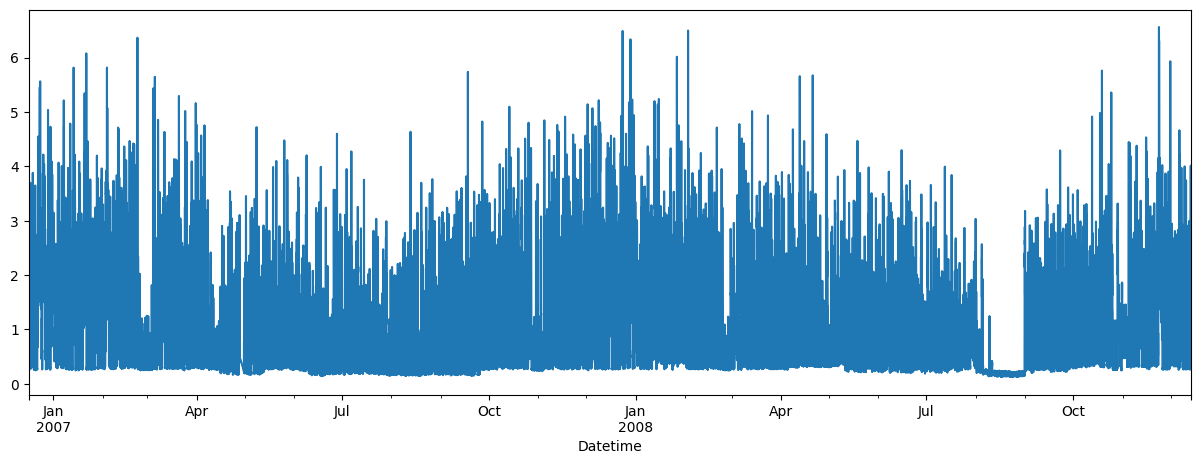

In [203]:
ts.plot(figsize=(15,5))

In [204]:
df_hourly.to_csv("hourly_power_consumption.csv")
print("✅ Saved file: hourly_power_consumption.csv")

✅ Saved file: hourly_power_consumption.csv
